In [1]:
with open("names.txt", 'r') as f:
    words = f.read().splitlines()

In [2]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
len(words)

32033

In [4]:
min(len(w) for w in words)

2

In [5]:
max(len(w) for w in words)

15

In [6]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for c1, c2 in zip(chs, chs[1:]):
        bigram = (c1, c2)
        b[bigram] = b.get(bigram, 0) + 1

In [7]:
sorted(b.items(), key=lambda kv: kv[1], reverse=True)

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [8]:
import torch

In [9]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [10]:
# 26 letters + special 'start' and 'end' character = 28
N = torch.zeros((27, 27), dtype=torch.int32)


In [11]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for c1, c2 in zip(chs, chs[1:]):
        ix1 = stoi[c1]
        ix2 = stoi[c2]
        N[ix1, ix2] += 1

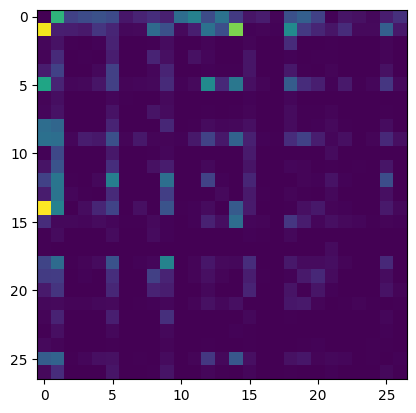

In [12]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N)

In [13]:
# need a better visualization

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

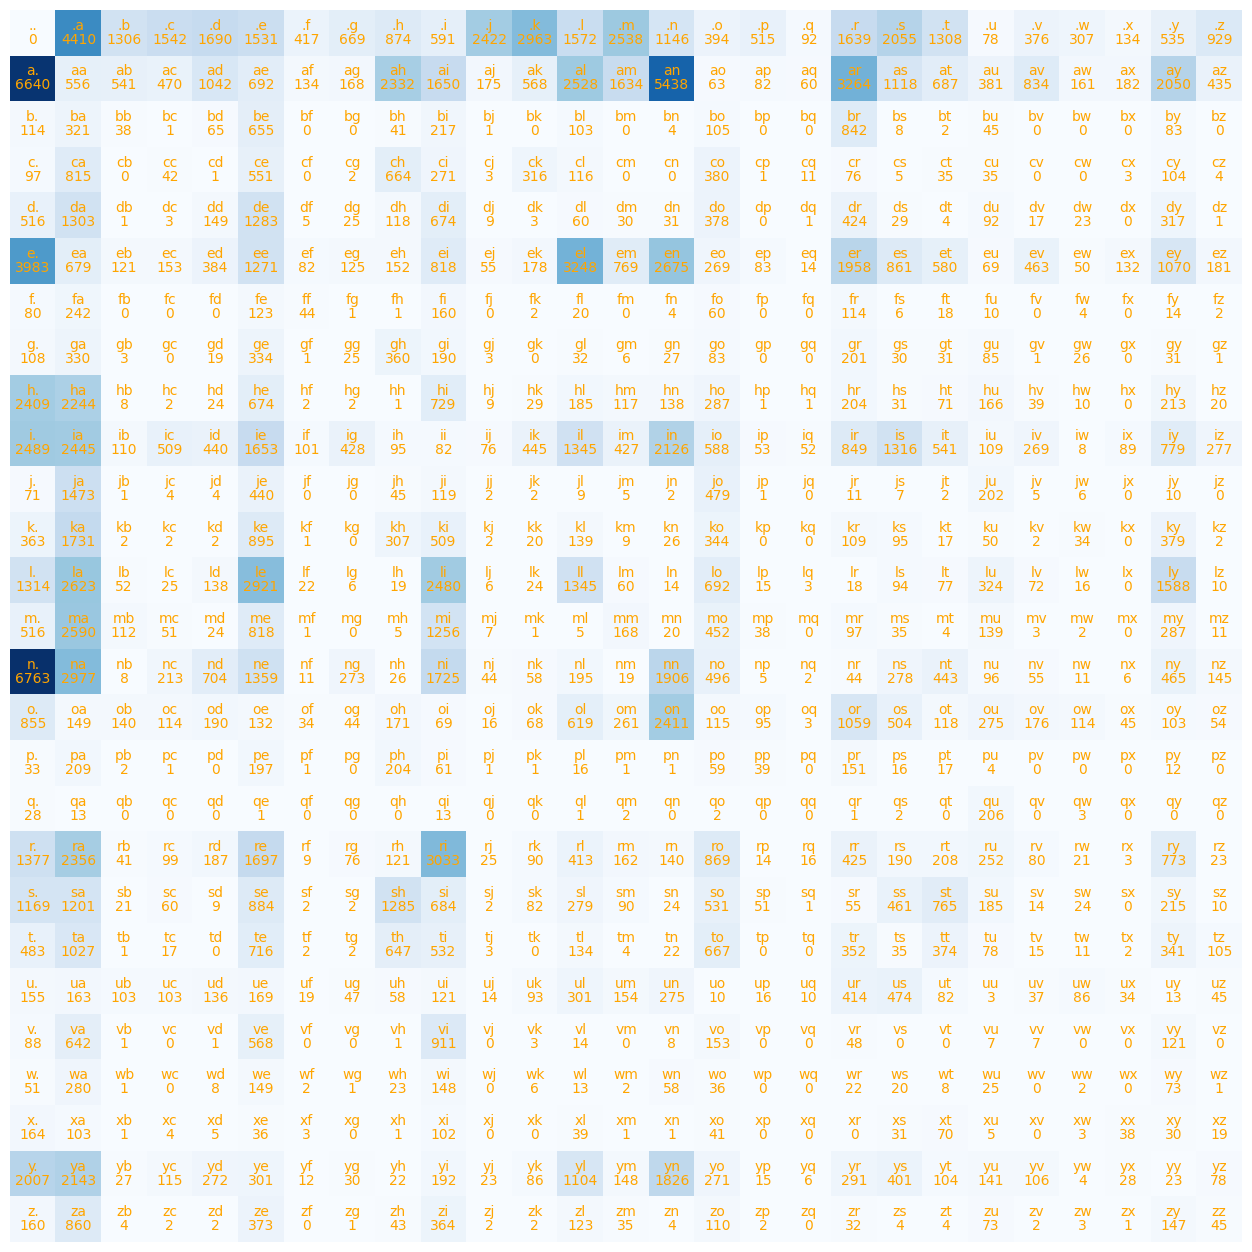

In [14]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="orange")
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="orange")
plt.axis('off')

In [15]:
# row 0 shows all the starting characters (char following '.')
# column 0 shows all the ending characters('.' following char)
# now creating a probability distribution for the first row

In [16]:
### Aside ###
# use torch.multinomial to sample from the distribution
# use a generator to make deterministic
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p / p.sum()
p
# the values in p are now the probability that the underlying value will be sampled
# 0 = 60%, 1 = 30%, 2 = 10%

tensor([0.6064, 0.3033, 0.0903])

In [17]:
# replacement=True allows the sampled value to be put back in the population
# to potentially be sampled again
torch.multinomial(p, num_samples=100, replacement=True, generator=g)
# based on above probabilities, should be ~60% 0's, 30% 1's, ...

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0,
        0, 1, 1, 1])

In [18]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [19]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [20]:
# now applying to the real values
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

'f'

In [21]:
# to get rid of an inefficiency below, 
# pulling out the float, sum, divide ops and performing once at the start
P = N.float()
# torch.sum allows summing across specified dimension
# dimension 1 is columns, so we sum each row into a single column vector
# keepdim maintains the number of dimension, just one of them goes to 1 -> the one we sum along
### This is important for math operations later if the dimension gets "squeezed" out then 
# the broadcasting rules will do something undesired
P.sum(1, keepdim=True).shape

torch.Size([27, 1])

In [22]:
# now we need to divide P [27, 27] by a [27, 1]...
# torch broadcasting semantics define these possible operations
# in this case we get elementwise division, which is what we want
# using 'in-place' operations also may have an efficiency gain
P /= P.sum(1, keepdim=True)

In [42]:
#### Now with model smoothing ####
P = (N+1).float()
P /= P.sum(1, keepdim=True)

In [43]:
# put together in a loop
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
    out = []
    ix = 0
    while True:
        # p = N[ix].float()
        # p = p / p.sum()
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


In [44]:
### Loss Function ###
log_likelihood = 0.0
n = 0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for c1, c2 in zip(chs, chs[1:]):
        ix1 = stoi[c1]
        ix2 = stoi[c2]
        prob = P[ix1, ix2]
        # log prob: closer to 0 => more negative logprob
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        # print(f'{c1}{c2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
# normal max of this is 0 so use neg log likelihood
# then minimizing loss = maximizing quality
# use the average
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-559951.5625)
nll=tensor(559951.5625)
2.4543561935424805


In [45]:
### Loss Function ###
def ave_nll(words, printeach=False):
    log_likelihood = 0.0
    n = 0
    for w in words:
        chs = ['.'] + list(w) + ['.']
        for c1, c2 in zip(chs, chs[1:]):
            ix1 = stoi[c1]
            ix2 = stoi[c2]
            prob = P[ix1, ix2]
            # log prob: closer to 0 => more negative logprob
            logprob = torch.log(prob)
            log_likelihood += logprob
            n += 1
            if printeach:
                print(f'{c1}{c2}: {prob:.4f} {logprob:.4f}')
    return -log_likelihood/n

print(f'{ave_nll(words)}')

2.4543561935424805


In [48]:
# because some of the probabilities are 0, if any of them are encountered we get an infinite loss
# This is undesirable, so we add a model smoothing to the counts
# adding less is a more peaky model, adding more is a smoother model
# we added 1 above here: P = (N+1).float()
print(f'{ave_nll(['andrej'])=}')
print(f'{ave_nll(['andrejq'], True)}')

ave_nll(['andrej'])=tensor(3.0368)
.a: 0.1376 -1.9835
an: 0.1604 -1.8302
nd: 0.0384 -3.2594
dr: 0.0770 -2.5646
re: 0.1334 -2.0143
ej: 0.0027 -5.9004
jq: 0.0003 -7.9817
q.: 0.0970 -2.3331
3.4834020137786865


In [26]:
# Expected probability
1/27

0.037037037037037035

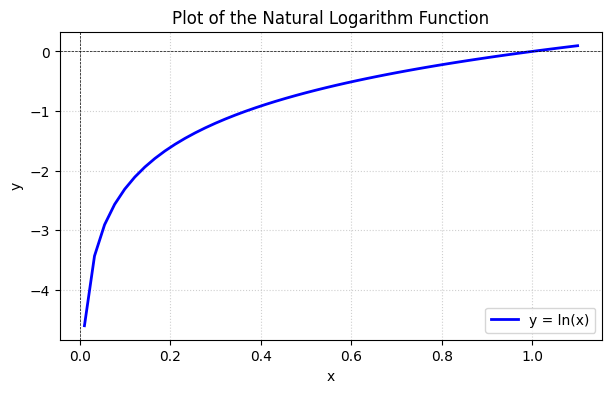

In [29]:
# any prob above 0.04 means we've learned something, these are more likely than average
# for a loss function: 
# how can we summarize the probabilites of all the bigrams in a word 
# to measure the quality of the model?
# Likelihood = product of all probabilities
# the product of a group of #'s between 0 and 1 is very small so we work with the log likelihood
# log(a*b*c) = log(a) + log(b) + log(c)
import matplotlib.pyplot as plt
import numpy as np

# Generate x values strictly greater than 0
x = np.linspace(0.01, 1.1, 50)
y = np.log(x)  # Natural logarithm (base e). Use np.log10(x) for base 10.

# Create the plot
plt.figure(figsize=(7, 4))
plt.plot(x, y, label='y = ln(x)', color='blue', linewidth=2)

# Format the chart
plt.title('Plot of the Natural Logarithm Function')
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')  # X-axis line
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')  # Y-axis line
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# Display the figure
plt.show()

In [53]:
# Now cast the problem into a neural network framework

# create the training set of all the bigrams (x, y)
# given the first char of a bigram, trying to predict the next one
xs, ys = [], []

for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for c1, c2 in zip(chs, chs[1:]):
        ix1 = stoi[c1]
        ix2 = stoi[c2]
        print(c1, c2)
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
# note: torch.tensor vs torch.Tensor
# torch.tensor infers the datatype automatically
# torch.Tensor is a float32 by default

. e
e m
m m
m a
a .


In [51]:
# input data set
xs

tensor([ 0,  5, 13, 13,  1])

In [52]:
# output data set
ys

tensor([ 5, 13, 13,  1,  0])

In [66]:
# initialization weights
W = torch.randn((27, 1))
# '@' is matrix multiplication operator in pytorch
# (5, 27) @ (27, 1) = (5, 1)
# the 27's multiply and add together


In [58]:
# not ideal/typical/desired to plug an integer index into the network
# so use "one hot" encoding
# given an integer, set the ith index of an array of 0's to 1
# use the built in torch.nn.functional.one_hot function
# cast to float as the desired dtype for nn input
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [59]:
xenc.shape

torch.Size([5, 27])

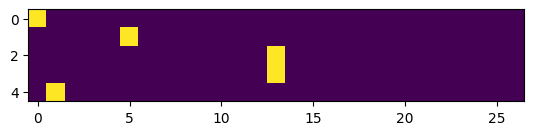

In [60]:
plt.imshow(xenc)

In [67]:
xenc @ W

tensor([[ 1.1619],
        [-0.3302],
        [ 0.3729],
        [ 0.3729],
        [-0.2448]])

In [ ]:
### ------------------------------------
### SUMMARY ----------------------------

In [78]:
# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
# (5, 27) @ (27, 27) = (5, 27)
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g)

In [79]:
# input to the network: one-hot encoding
xenc = F.one_hot(xs, num_classes=27).float()

In [80]:
# this is telling us the firing rate of each neuron for each of 5 examples
# Want to get a representation of the probability of the next char
# probabilities need to sum to 1
# currently getting "log counts"
# exp to get an equivalent/interpretation of "counts"
# neg #'s go to [0:1), pos #'s go to > 1

In [81]:
xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W # log counts
counts = logits.exp() # equivalent to N array above
probs = counts / counts.sum(1, keepdim=True)
probs

tensor([[0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
         0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
         0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459],
        [0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
         0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
         0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0150, 0.0086,

In [82]:
probs[0].sum()

tensor(1.0000)

In [83]:
probs[0]

tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])

In [84]:
# to summarize current ops:
# for each char in an input word
# char index -> one_hot encode -> mult w -> exp -> normalize

In [85]:
# Printed example
nlls = torch.zeros(5)
for i in range(5):
    # i-th bigram:
    x = xs[i].item()  # input character index
    y = ys[i].item()  # label character index
    print('------------')
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
    print(f'input to the neural net: {x}')
    print(f'output probabilities from the neural net: {probs[i]}')
    print(f'label (actual next character): {y}')
    p = probs[i, y]
    print('probability assigned by the net to the correct character:', p.item())
    logp = torch.log(p)
    print('log likelihood:', logp.item())
    nll = -logp
    print('negative log likelihood:', nll.item())
    nlls[i] = nll
print('=============')
print('average negative log likelihood, i.e. loss = ', nlls.mean().item())

------------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label (actual next character): 5
probability assigned by the net to the correct character: 0.01228625513613224
log likelihood: -4.399273872375488
negative log likelihood: 4.399273872375488
------------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
label (actual next character): 13
probability assigned by the net to the correct character: 0.

In [86]:
# ----------------- OPTIMIZATION -------------------

In [87]:
xs

tensor([ 0,  5, 13, 13,  1])

In [88]:
ys

tensor([ 5, 13, 13,  1,  0])

In [115]:
# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
# (5, 27) @ (27, 27) = (5, 27)
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [132]:
# Forward Pass
xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W # log counts
counts = logits.exp() # equivalent to N array above
probs = counts / counts.sum(1, keepdim=True)
loss = -probs[torch.arange(5), ys].log().mean()

In [133]:
print(loss.item())

3.7291626930236816


In [117]:
probs.shape

torch.Size([5, 27])

In [118]:
# to get the probs for each of the chars in our input example:
probs[0, 5], probs[1, 13], probs[2, 13], probs[3, 1], probs[4, 0]

(tensor(0.0123, grad_fn=<SelectBackward0>),
 tensor(0.0181, grad_fn=<SelectBackward0>),
 tensor(0.0267, grad_fn=<SelectBackward0>),
 tensor(0.0737, grad_fn=<SelectBackward0>),
 tensor(0.0150, grad_fn=<SelectBackward0>))

In [119]:
# this can be done better...
torch.arange(5)

tensor([0, 1, 2, 3, 4])

In [120]:
loss = -probs[torch.arange(5), ys].log().mean()
loss

tensor(3.7693, grad_fn=<NegBackward0>)

In [129]:
# backward pass
W.grad = None # same effect as setting gradient to 0
# pytorch is keeping track of the graph and all the ops
loss.backward()

In [122]:
W.shape

torch.Size([27, 27])

In [123]:
W.grad.shape

torch.Size([27, 27])

In [124]:
# each gradient is telling us the influece of the associated value on the loss
# positive grad -> adding to value increases loss
W.grad

tensor([[ 0.0121,  0.0020,  0.0025,  0.0008,  0.0034, -0.1975,  0.0005,  0.0046,
          0.0027,  0.0063,  0.0016,  0.0056,  0.0018,  0.0016,  0.0100,  0.0476,
          0.0121,  0.0005,  0.0050,  0.0011,  0.0068,  0.0022,  0.0006,  0.0040,
          0.0024,  0.0307,  0.0292],
        [-0.1970,  0.0017,  0.0079,  0.0020,  0.0121,  0.0062,  0.0217,  0.0026,
          0.0025,  0.0010,  0.0205,  0.0017,  0.0198,  0.0022,  0.0046,  0.0041,
          0.0082,  0.0016,  0.0180,  0.0106,  0.0093,  0.0062,  0.0010,  0.0066,
          0.0131,  0.0101,  0.0018],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000

In [130]:
# Update does not require a loop, only one parameter: W
W.data += -0.1 * W.grad

In [131]:
print(loss.item())

3.7492127418518066


In [141]:
# Rearrange an organize above
# create the dataset
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the network
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  228146


In [144]:
# regularization component of loss:
# equivalent of adding counts to smooth
(W**2).mean()

tensor(2.1080, grad_fn=<MeanBackward0>)

In [148]:
# gradient descent
for k in range(100):

    # forward pass
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ W # log counts
    counts = logits.exp() # equivalent to N array above
    probs = counts / counts.sum(1, keepdim=True)
    loss = -probs[torch.arange(num), ys].log().mean() + 0.1*(W**2).mean()
    print(loss.item())

    # backward pass
    W.grad = None
    loss.backward()

    # update
    W.data += -50 * W.grad

2.5863962173461914
2.586395263671875
2.5863943099975586
2.586393356323242
2.586392641067505
2.5863916873931885
2.586390733718872
2.5863900184631348
2.5863893032073975
2.586388349533081
2.5863876342773438
2.5863869190216064
2.586386203765869
2.586385726928711
2.5863847732543945
2.586383819580078
2.586383104324341
2.5863828659057617
2.5863819122314453
2.586381435394287
2.586380958557129
2.5863802433013916
2.5863797664642334
2.586379289627075
2.586379289627075
2.586378574371338
2.5863778591156006
2.5863776206970215
2.5863771438598633
2.586376667022705
2.586376428604126
2.5863759517669678
2.5863754749298096
2.5863752365112305
2.5863747596740723
2.586374282836914
2.586373805999756
2.586373805999756
2.5863733291625977
2.5863728523254395
2.5863728523254395
2.5863723754882812
2.586372137069702
2.586371898651123
2.586371898651123
2.5863709449768066
2.5863711833953857
2.5863711833953857
2.5863707065582275
2.5863704681396484
2.5863699913024902
2.5863699913024902
2.586369752883911
2.58636927604675

In [149]:
# finally, sample from the 'neural net'
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
        # BEFORE
        # p = P[ix]
        # NOW
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc @ W  # predict log counts
        counts = logits.exp()  # counts, equivalent to N
        p = counts / counts.sum(1, keepdim=True) #probabilities for next character
        # ----

        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momakurailezityha.
konimittain.
llayn.
ka.
